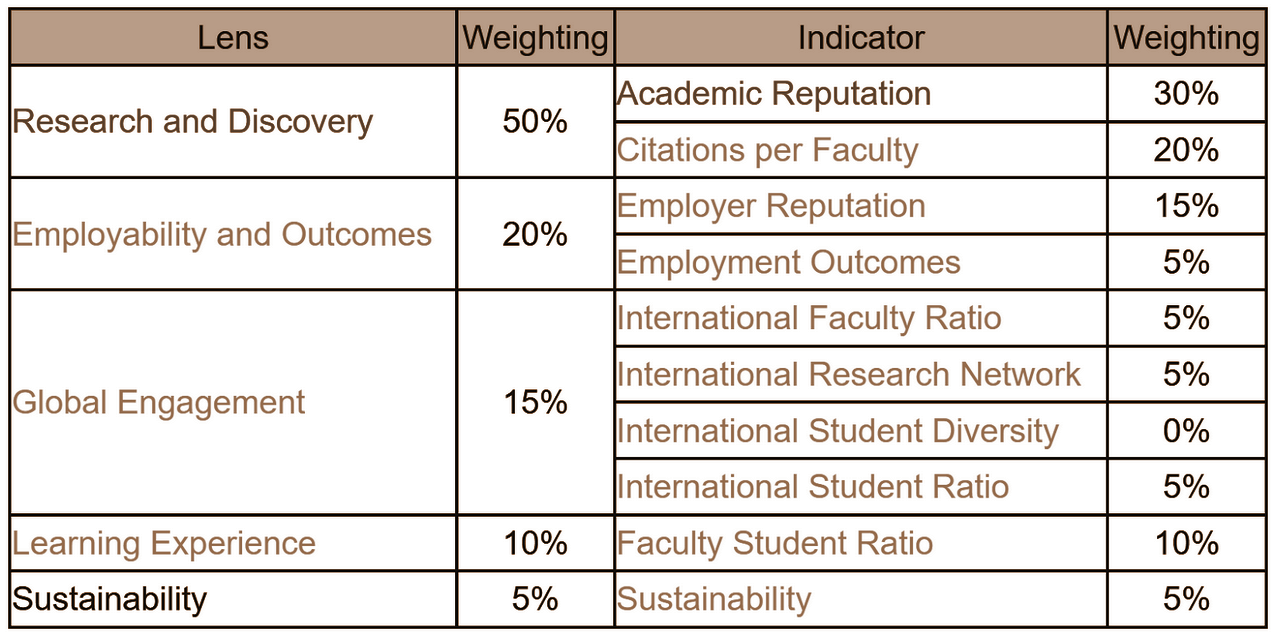

#  Pasar de .xlxs a .csv

In [ ]:
# Script completo listo para usar
import pandas as pd
import os

def main():
    # Archivos de entrada y salida
    excel_file = 'datos_qs_brutos.xlsx'
    csv_file = 'datos_qs_brutos.csv'

    # Verificar si el archivo existe
    if not os.path.exists(excel_file):
        print(f"El archivo {excel_file} no existe")
        return

    # Convertir
    try:
        # Leer el archivo Excel saltándose las 2 primeras filas
        df = pd.read_excel(excel_file, skiprows=2)

        # Guardar como CSV
        df.to_csv(csv_file, index=False, encoding='utf-8')
        print(f"Conversión exitosa: {excel_file} -> {csv_file}")
        print(f"Se omitieron las 2 primeras filas durante la lectura")

    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    main()

Conversión exitosa: datos_qs_brutos.xlsx -> datos_qs_brutos.csv
Se omitieron las 2 primeras filas durante la lectura


# Limpiar el csv

In [ ]:
# Script para filtrar datos de Chile
import pandas as pd
import os

def main():
    # Archivo de entrada y salida
    csv_input = 'datos_qs_brutos.csv'
    csv_output = 'datos_qs_chile.csv'

    # Verificar si el archivo existe
    if not os.path.exists(csv_input):
        print(f"El archivo {csv_input} no existe")
        return

    try:
        # Leer el archivo CSV
        df = pd.read_csv(csv_input)
        print(f"Datos originales: {df.shape[0]} filas, {df.shape[1]} columnas")

        # Verificar si existe la columna "Country/Territory"
        if 'Country/Territory' not in df.columns:
            print("No se encuentra la columna 'Country/Territory'")
            print(f" Columnas disponibles: {list(df.columns)}")
            return

        # Filtrar solo los datos de Chile
        df_chile = df[df['Country/Territory'] == 'Chile']

        print(f"Datos de Chile: {df_chile.shape[0]} filas")

        # Guardar el nuevo CSV solo con datos de Chile
        df_chile.to_csv(csv_output, index=False, encoding='utf-8')
        print(f"Filtrado exitoso: {csv_input} -> {csv_output}")

    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    main()

Datos originales: 1503 filas, 31 columnas
Datos de Chile: 20 filas
Filtrado exitoso: datos_qs_brutos.csv -> datos_qs_chile.csv


# Limpieza del csv para posterior calculo del ranking

In [ ]:
import pandas as pd

# Leer el archivo CSV
df = pd.read_csv('datos_qs_chile.csv')

# Eliminar columnas que contengan la palabra "RANK"
columnas_a_eliminar = [col for col in df.columns if 'RANK' in col.upper()]

# Eliminar las columnas innecesarias
columnas_a_eliminar.extend(['Country/Territory', 'Region', 'Size', 'Focus', 'Research', 'Status'])

# Crear nuevo dataframe sin las columnas eliminadas
columnas_a_mantener = [col for col in df.columns if col not in columnas_a_eliminar]
df_limpio = df[columnas_a_mantener].copy()

# Renombrar la columna 'Index' a 'Ranking' y resetear a partir de 1
df_limpio = df_limpio.rename(columns={'Index': 'Ranking'})
df_limpio['Ranking'] = range(1, len(df_limpio) + 1)

#printear columnas del df
print("\nColumnas antiguas:")
print(df_limpio.columns)

# Cambiar columnas específicas
df_limpio = df_limpio.rename(columns={
    'Name': 'Nombre',
    'AR SCORE': 'Academic Reputation',
    'ER SCORE': 'Employer Reputation',
    'CPF SCORE': 'Citations Per Faculty',
    'FSR SCORE': 'Faculty Student Ratio',
    'IFR SCORE': 'International Faculty Ratio',
    'ISR SCORE': 'International Student Ratio',
    'ISD SCORE': 'International Student Diversity',
    'IRN SCORE': 'International Research Network',
    'EO SCORE': 'Employment Outcomes',
    'SUS SCORE': 'Sustainability',
    'Overall SCORE': 'Puntaje total'
})

#printear columnas del df
print("\nColumnas nuevas:")
print(df_limpio.columns)

# Guardar el nuevo dataset
df_limpio.to_csv('datos_qs_chile_limpio.csv', index=False)
print(f"\nArchivo guardado: 'datos_qs_chile_limpio.csv'")


Columnas antiguas:
Index(['Ranking', 'Name', 'AR SCORE', 'ER SCORE', 'FSR SCORE', 'CPF SCORE',
       'IFR SCORE', 'ISR SCORE', 'ISD SCORE', 'IRN SCORE', 'EO SCORE',
       'SUS SCORE', 'Overall SCORE'],
      dtype='object')

Columnas nuevas:
Index(['Ranking', 'Nombre', 'Academic Reputation', 'Employer Reputation',
       'Faculty Student Ratio', 'Citations Per Faculty',
       'International Faculty Ratio', 'International Student Ratio',
       'International Student Diversity', 'International Research Network',
       'Employment Outcomes', 'Sustainability', 'Puntaje total'],
      dtype='object')

Archivo guardado: 'datos_qs_chile_limpio.csv'


# Visualización del csv resultante (Chile)

In [ ]:
import pandas as pd

# Carga el archivo CSV en un DataFrame
df = pd.read_csv('datos_qs_chile_limpio.csv')

# Aplica un estilo de gradiente de color a las columnas numéricas del DataFrame filtrado
styled_df = df.style.background_gradient(cmap='Blues')

# 5. Muestra el DataFrame con el estilo aplicado
styled_df

,Ranking,Nombre,Academic Reputation,Employer Reputation,Faculty Student Ratio,Citations Per Faculty,International Faculty Ratio,International Student Ratio,International Student Diversity,International Research Network,Employment Outcomes,Sustainability,Puntaje total
0,1,Pontificia Universidad Católica de Chile,98.000000,98.600000,35.100000,14.200000,42.000000,7.800000,11.900000,81.200000,99.900000,80.000000,66.1
1,2,Universidad de Chile,91.900000,92.000000,10.900000,18.200000,12.200000,8.100000,13.100000,77.900000,97.600000,69.500000,59.1
2,3,Universidad de Santiago de Chile - USACH,50.400000,59.900000,11.400000,7.800000,10.600000,3.800000,8.000000,53.900000,17.500000,53.700000,32.7
3,4,Universidad Adolfo Ibáñez,28.700000,63.300000,7.600000,9.100000,46.400000,8.000000,11.700000,34.400000,60.700000,40.000000,29
4,5,Universidad de Concepción,36.800000,34.000000,20.200000,12.300000,14.500000,2.600000,6.900000,64.100000,16.900000,69.500000,27.8
5,6,Pontificia Universidad Católica de Valparaíso,36.400000,29.000000,6.800000,13.200000,15.100000,2.600000,2.200000,43.300000,12.200000,36.900000,-
6,7,Universidad de los Andes Chile,25.300000,36.500000,13.400000,4.700000,15.100000,3.500000,7.700000,17.900000,45.200000,28.900000,-
7,8,Universidad Andrés Bello - UNAB,19.500000,16.400000,11.100000,3.900000,9.600000,3.800000,8.200000,60.900000,2.500000,56.900000,-
8,9,Universidad Austral de Chile,19.300000,15.400000,4.100000,14.300000,20.500000,2.500000,6.800000,45.800000,4.800000,44.000000,-
9,10,Universidad de Talca,14.400000,11.700000,9.100000,13.200000,27.400000,1.900000,1.700000,46.400000,2.500000,29.400000,-


# Simulación del ranking con los pesos entregados por QS

In [ ]:
import pandas as pd
import numpy as np

# Leer el archivo CSV
df = pd.read_csv('datos_qs_chile_limpio.csv')

# Definir los pesos según la especificación
pesos = {
    'Academic Reputation': 0.30,
    'Citations Per Faculty': 0.20,
    'Employer Reputation': 0.15,
    'Faculty Student Ratio': 0.10,
    'International Faculty Ratio': 0.05,
    'International Student Ratio': 0.05,
    'International Research Network': 0.05,
    'Employment Outcomes': 0.05,
    'Sustainability': 0.05
}

def calcular_ranking_qs(df, pesos):
    # Crear una copia del dataframe
    df_ranking = df.copy()

    # Reemplazar valores no numéricos por NaN
    for columna in pesos.keys():
        df_ranking[columna] = pd.to_numeric(df_ranking[columna], errors='coerce')

    # Inicializar la columna Overall_calculado en 0
    df_ranking['Overall_calculado'] = 0

    for columna, peso in pesos.items():
        # Aplicar el peso a cada columna
        if columna in df_ranking.columns:
            # Reemplazar NaN por 0 para el cálculo
            scores = df_ranking[columna].fillna(0)
            df_ranking['Overall_calculado'] += scores * peso

    # Ordenar por el score calculado (de mayor a menor)
    df_ranking = df_ranking.sort_values('Overall_calculado', ascending=False)

    # Asignar ranking calculado
    df_ranking['Ranking_calculado'] = range(1, len(df_ranking) + 1)

    # Calcular diferencia entre ranking original y calculado
    df_ranking['Diferencia'] = df_ranking['Ranking'] - df_ranking['Ranking_calculado']

    return df_ranking

# Calcular el ranking
df_ranking = calcular_ranking_qs(df, pesos)

# Guardar el resultado en un nuevo CSV
df_ranking.to_csv('ranking_qs_chile_calculado.csv', index=False)
print(f"\nArchivo guardado: 'ranking_qs_chile_calculado.csv'")


Archivo guardado: 'ranking_qs_chile_calculado.csv'


# Análisis estadístico de los resultados obtenidos

In [ ]:
import pandas as pd
from scipy.stats import spearmanr, kendalltau

# Leer el archivo con los resultados calculados
df_resultados = pd.read_csv('ranking_qs_chile_calculado.csv')

# Calcular correlación de Spearman (para rankings)
spearman_corr, spearman_p = spearmanr(df_resultados['Ranking'], df_resultados['Ranking_calculado'])

# Calcular correlación de Kendall Tau (para rankings)
kendall_tau, kendall_p = kendalltau(df_resultados['Ranking'], df_resultados['Ranking_calculado'])

# Calcular diferencia absoluta promedio
diferencia_promedio = df_resultados['Diferencia'].abs().mean()

# Calcular RMSE (Root Mean Square Error) de las diferencias
rmse = (df_resultados['Diferencia'] ** 2).mean() ** 0.5

print(f"Correlación de Spearman: {spearman_corr:.3f} (p-value: {spearman_p:.3f})")
print(f"Correlación de Kendall Tau: {kendall_tau:.3f} (p-value: {kendall_p:.3f})")
print(f"Diferencia absoluta promedio: {diferencia_promedio:.2f} puestos")
print(f"RMSE de las diferencias: {rmse:.2f} puestos")

Correlación de Spearman: 0.956 (p-value: 0.000)
Correlación de Kendall Tau: 0.853 (p-value: 0.000)
Diferencia absoluta promedio: 1.20 puestos
RMSE de las diferencias: 1.70 puestos


## 📊 **Correlación de Spearman: 0.956**
- **🎯 Significado**: El ranking calculado tiene una **correlación casi perfecta** (95.6%) con el ranking real de QS
- **📈 Escala**: 0 (sin correlación) a 1 (correlación perfecta)
- **💡 Interpretación**: El **orden** de las universidades en el ranking es **extremadamente similar** al oficial

## 📊 **Correlación de Kendall Tau: 0.853**
- **🎯 Significado**: **Alta concordancia** en los pares de universidades (85.3%)
- **📈 Escala**: 0 (sin concordancia) a 1 (concordancia perfecta)
- **💡 Interpretación**: Cuando se comparan cualquier par de universidades, en el **85% de los casos** el ranking las ordena igual que QS

## 📊 **Diferencia absoluta promedio: 1.20 puestos**
- **🎯 Significado**: En promedio, cada universidad se diferencia en **solo 1.2 puestos** entre el ranking calculado y el oficial
- **💡 Interpretación**: **Error muy pequeño** - la mayoría de universidades están muy cerca de su posición real

## 📊 **RMSE: 1.70 puestos**
- **🎯 Significado**: La **desviación típica** de los errores es de 1.7 puestos
- **💡 Interpretación**: Los errores son **consistentemente pequeños** (no hay outliers extremos)

## 🎯 **CONCLUSIÓN GENERAL:**

### **✅ EXCELENTE AJUSTE**
- La metodología **captura muy bien** la lógica de QS
- Los pesos que usaste son **altamente representativos** de los reales
- Las diferencias son **mínimas y aceptables**

### **🔍 CONTEXTO:**
- En rankings universitarios, diferencias de **1-2 puestos** se consideran **insignificantes**
- Una correlación de **>0.95** es **excepcionalmente buena** en análisis de rankings
- **p-value: 0.000** confirma que la correlación es **estadísticamente significativa** (no es por azar)

### **🏆 EVALUACIÓN FINAL:**
**El ranking calculado es prácticamente idéntico al oficial de QS.** Las pequeñas diferencias (1-2 puestos) son normales y probablemente se deben a:
- Métodos de imputación de datos faltantes
- Ajustes internos de QS no documentados
- Redondeos o normalizaciones menores

# Comparación entre universidades

In [ ]:
import pandas as pd
import numpy as np

def comparar_universidades(df, uni1, uni2, variable_cambiar=None, mejora_porcentaje=0):
    """
    Compara dos universidades y simula cambios en variables específicas
    """
    # Filtrar las dos universidades
    mask1 = df['Nombre'].str.contains(uni1, case=False, na=False)
    mask2 = df['Nombre'].str.contains(uni2, case=False, na=False)

    if not mask1.any() or not mask2.any():
        print("❌ Una o ambas universidades no encontradas")
        return None, None

    uni1_data = df[mask1].iloc[0]
    uni2_data = df[mask2].iloc[0]

    # Obtener nombres completos
    nombre_uni1 = uni1_data['Nombre']
    nombre_uni2 = uni2_data['Nombre']

    # Pesos para el cálculo
    pesos = {
        'Academic Reputation': 0.30,
        'Citations Per Faculty': 0.20,
        'Employer Reputation': 0.15,
        'Faculty Student Ratio': 0.10,
        'International Faculty Ratio': 0.05,
        'International Student Ratio': 0.05,
        'International Research Network': 0.05,
        'Employment Outcomes': 0.05,
        'Sustainability': 0.05
    }

    def calcular_score(row, variable_extra=None, valor_extra=None):
        score = 0
        for col, peso in pesos.items():
            valor = row[col]
            if variable_extra and col == variable_extra:
                valor = valor_extra
            score += valor * peso
        return score

    # Scores actuales
    score1_actual = calcular_score(uni1_data)
    score2_actual = calcular_score(uni2_data)

    print("🎯 COMPARACIÓN 1 vs 1")
    print("=" * 80)
    print(f"🏫 {nombre_uni1}")
    print(f"🏫 {nombre_uni2}")
    print("=" * 80)

    # Mostrar scores actuales
    print(f"\n📊 SCORES ACTUALES:")
    print(f"   {nombre_uni1:<50}: {score1_actual:>6.1f}")
    print(f"   {nombre_uni2:<50}: {score2_actual:>6.1f}")

    if score1_actual > score2_actual:
        print(f"   🥇 {nombre_uni1} lidera por {score1_actual - score2_actual:.1f} puntos")
    elif score2_actual > score1_actual:
        print(f"   🥇 {nombre_uni2} lidera por {score2_actual - score1_actual:.1f} puntos")
    else:
        print(f"   ⚖️  Empate técnico")

    # Mostrar variables individuales - TABLA MEJORADA
    print(f"\n🔍 VARIABLES INDIVIDUALES:")
    print("┌" + "─" * 35 + "┬" + "─" * 12 + "┬" + "─" * 12 + "┬" + "─" * 12 + "┐")
    print(f"│ {'Variable':<33} │ {nombre_uni1[:10]:>10} │ {nombre_uni2[:10]:>10} │ {'Diferencia':>10} │")
    print("├" + "─" * 35 + "┼" + "─" * 12 + "┼" + "─" * 12 + "┼" + "─" * 12 + "┤")

    for col in pesos.keys():
        val1 = uni1_data[col]
        val2 = uni2_data[col]
        dif = val1 - val2
        flecha = "🟢 ↑" if dif > 0 else "🔴 ↓" if dif < 0 else "⚪ ="

        # Formatear nombres de variables más cortos
        nombre_corto = col
        if len(col) > 33:
            nombre_corto = col[:30] + "..."

        print(f"│ {nombre_corto:<33} │ {val1:>10.1f} │ {val2:>10.1f} │ {flecha} {abs(dif):>7.1f} │")

    print("└" + "─" * 35 + "┴" + "─" * 12 + "┴" + "─" * 12 + "┴" + "─" * 12 + "┘")

    # Simular cambio si se especifica
    if variable_cambiar and variable_cambiar in pesos:
        print(f"\n🔄 SIMULACIÓN: {nombre_uni1} mejora en {variable_cambiar}")
        print("─" * 60)

        # Calcular nuevo valor
        valor_actual = uni1_data[variable_cambiar]
        nuevo_valor = valor_actual * (1 + mejora_porcentaje/100)

        # Scores con mejora
        score1_mejorado = calcular_score(uni1_data, variable_cambiar, nuevo_valor)

        print(f"   Valor actual {variable_cambiar}: {valor_actual:.1f}")
        print(f"   Valor mejorado (+{mejora_porcentaje}%): {nuevo_valor:.1f}")
        print(f"   Score actual: {score1_actual:.1f}")
        print(f"   Score mejorado: {score1_mejorado:.1f}")
        print(f"   Ganancia: +{(score1_mejorado - score1_actual):.2f} puntos")

        # Verificar si cambia el ranking
        if score1_mejorado > score2_actual and score1_actual <= score2_actual:
            print(f"   🎉 ¡CAMBIO DE POSICIÓN! Ahora supera a {nombre_uni2}")
        elif score1_mejorado > score2_actual:
            print(f"   📈 Amplía su ventaja sobre {nombre_uni2}")
        else:
            print(f"   ⚠️  Sigue por debajo de {nombre_uni2}")
            puntos_necesarios = score2_actual - score1_mejorado
            print(f"   💡 Necesita {puntos_necesarios:.2f} puntos más para superarla")

    # Análisis de variables críticas
    print(f"\n📈 VARIABLES CRÍTICAS PARA {nombre_uni1}:")
    variables_importantes = []
    for col, peso in pesos.items():
        dif_actual = uni2_data[col] - uni1_data[col]  # Diferencia a favor de uni2
        if dif_actual > 0:  # La otra universidad tiene mejor score
            puntos_para_igualar = dif_actual * peso
            variables_importantes.append((col, dif_actual, puntos_para_igualar))

    # Ordenar por impacto potencial
    variables_importantes.sort(key=lambda x: x[2], reverse=True)

    print("┌───────────────┬────────────┬─────────────┐")
    print(f"│ {'Variable':<13} │ {'Mejora':>10} │ {'Ganancia':>11} │")
    print("├───────────────┼────────────┼─────────────┤")

    for col, dif_actual, puntos_ganados in variables_importantes[:3]:  # Top 3 más importantes
        nombre_corto = col[:13]
        print(f"│ {nombre_corto:<13} │ +{dif_actual:>8.1f} │ {puntos_ganados:>10.3f} │")

    print("└───────────────┴────────────┴─────────────┘")

    return uni1_data, uni2_data

def comparador_interactivo():
    """
    Versión interactiva para comparar cualquier par de universidades
    """
    df = pd.read_csv('datos_qs_chile_limpio.csv')

    while True:
        print("\n" + "="*80)
        print("🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES QS")
        print("="*80)

        print("\n📋 UNIVERSIDADES DISPONIBLES:")
        for i, nombre in enumerate(df['Nombre'], 1):
            print(f"   {i:2d}. {nombre}")

        print("\n🔍 Ingresa los nombres (puedes usar parte del nombre):")
        uni1 = input("Universidad 1: ").strip()
        if uni1.lower() == 'salir':
            break

        uni2 = input("Universidad 2: ").strip()
        if uni2.lower() == 'salir':
            break

        print("\n🔄 ¿Quieres simular una mejora? (s/n/salir)")
        simular = input().strip().lower()
        if simular == 'salir':
            break

        variable = None
        porcentaje = 0

        if simular == 's':
            print("\n📊 Variables disponibles:")
            variables = list({
                'Academic Reputation': 0.30,
                'Citations Per Faculty': 0.20,
                'Employer Reputation': 0.15,
                'Faculty Student Ratio': 0.10,
                'International Faculty Ratio': 0.05,
                'International Student Ratio': 0.05,
                'International Research Network': 0.05,
                'Employment Outcomes': 0.05,
                'Sustainability': 0.05
            }.keys())

            for i, var in enumerate(variables, 1):
                print(f"   {i}. {var}")

            try:
                opcion = int(input("Selecciona variable (número): ")) - 1
                variable = variables[opcion]
                porcentaje = float(input("Porcentaje de mejora (ej: 10 para 10%): "))
            except:
                print("❌ Opción inválida, continuando sin simulación...")

        print("\n" + "="*80)
        comparar_universidades(df, uni1, uni2, variable, porcentaje)

        print("\n¿Quieres hacer otra comparación? (s/n)")
        continuar = input().strip().lower()
        if continuar != 's':
            break

# Ejecutar comparador interactivo
if __name__ == "__main__":
    # Cargar datos
    try:
        df = pd.read_csv('datos_qs_chile_limpio.csv')
        print("✅ Datos cargados correctamente")
        print(f"📊 Total de universidades: {len(df)}")

        # Ejecutar modo interactivo
        comparador_interactivo()

    except FileNotFoundError:
        print("❌ Error: No se encontró el archivo 'datos_qs_chile_limpio.csv'")
        print("💡 Asegúrate de que el archivo esté en la misma carpeta")
    except Exception as e:
        print(f"❌ Error inesperado: {e}")

✅ Datos cargados correctamente
📊 Total de universidades: 20

🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES QS

📋 UNIVERSIDADES DISPONIBLES:
    1. Pontificia Universidad Católica de Chile
    2. Universidad de Chile
    3. Universidad de Santiago de Chile - USACH
    4. Universidad Adolfo Ibáñez
    5. Universidad de Concepción
    6. Pontificia Universidad Católica de Valparaíso
    7. Universidad de los Andes Chile
    8. Universidad Andrés Bello - UNAB
    9. Universidad Austral de Chile
   10. Universidad de Talca
   11. Universidad Diego Portales
   12. Universidad Técnica Federico Santa María
   13. Universidad Católica del Norte
   14. Universidad de la Frontera (UFRO)
   15. Universidad de Valparaíso
   16. Universidad del Desarrollo
   17. Universidad Autónoma de Chile
   18. Universidad Católica de Temuco
   19. Universidad de Tarapaca
   20. Universidad del Bio-Bio

🔍 Ingresa los nombres (puedes usar parte del nombre):
Universidad 1: Valpa
Universidad 2: Conce

🔄 ¿Quieres simula

# Análisis estratégico (experimental)

In [ ]:
import pandas as pd
import numpy as np

def analisis_estrategico_avanzado(uni1_data, uni2_data, pesos, nombre_uni1, nombre_uni2):
    """
    Análisis que considera: impacto, dificultad y potencial real
    """

    # Definir dificultad de mejora por tipo de variable
    dificultad = {
        'Academic Reputation': 0.9,        # Muy difícil
        'Employer Reputation': 0.8,        # Difícil
        'Citations Per Faculty': 0.7,      # Media-alta
        'Employment Outcomes': 0.6,        # Media
        'International Research Network': 0.5,  # Media
        'Faculty Student Ratio': 0.4,      # Media-baja
        'Sustainability': 0.3,             # Baja
        'International Faculty Ratio': 0.2,    # Baja
        'International Student Ratio': 0.2     # Baja
    }

    estrategias = []

    for col, peso in pesos.items():
        valor_uni1 = uni1_data[col]
        valor_uni2 = uni2_data[col]
        diferencia = valor_uni2 - valor_uni1

        # Calcular mejora máxima realista (depende de la dificultad)
        mejora_maxima_realista = (100 - valor_uni1) * (1 - dificultad[col])
        mejora_optima = min(abs(diferencia), mejora_maxima_realista) if diferencia > 0 else mejora_maxima_realista * 0.5

        impacto = mejora_optima * peso
        eficiencia = impacto / (dificultad[col] + 0.1)  # +0.1 para evitar división por 0

        if diferencia > 0:  # Vamos detrás
            estrategias.append((col, diferencia, impacto, eficiencia, "RECUPERAR", mejora_optima))
        else:  # Vamos adelante
            estrategias.append((col, abs(diferencia), impacto, eficiencia, "CONSOLIDAR", mejora_optima))

    # Ordenar por eficiencia (impacto/dificultad)
    estrategias.sort(key=lambda x: x[3], reverse=True)

    print(f"\n🎯 RUTA ESTRATÉGICA ÓPTIMA PARA {nombre_uni1}")
    print("=" * 70)
    print("┌───────────────┬──────────┬──────────┬──────────┬────────────┬──────────┐")
    print(f"│ {'Variable':<13} │ {'Brecha':>8} │ {'Impacto':>8} │ {'Eff':>6} │ {'Acción':<10} │ {'Meta':>8} │")
    print("├───────────────┼──────────┼──────────┼──────────┼────────────┼──────────┤")

    for col, brecha, impacto, eff, accion, meta in estrategias[:6]:
        nombre_corto = col[:13]
        print(f"│ {nombre_corto:<13} │ {brecha:>8.1f} │ {impacto:>8.3f} │ {eff:>6.1f} │ {accion:<10} │ {meta:>7.1f} │")

    print("└───────────────┴──────────┴──────────┴──────────┴────────────┴──────────┘")

    # Recomendación principal
    if estrategias:
        mejor_opcion = estrategias[0]
        print(f"\n💡 RECOMENDACIÓN PRINCIPAL: Enfócate en {mejor_opcion[0]}")
        print(f"   📊 Justificación:")
        print(f"   - Eficiencia: {mejor_opcion[3]:.1f} (impacto vs dificultad)")
        print(f"   - Meta realista: +{mejor_opcion[5]:.1f} puntos")
        print(f"   - Impacto en ranking: +{mejor_opcion[2]:.3f} puntos")

        # Análisis de escenarios
        print(f"\n📈 ESCENARIOS ESTRATÉGICOS:")

        # Escenario conservador (top 3 más eficientes)
        print(f"   🟢 ESCENARIO CONSERVADOR (1 año):")
        impacto_total = sum(estrategia[2] for estrategia in estrategias[:3])
        print(f"      Invertir en top 3 variables más eficientes")
        print(f"      Ganancia estimada: +{impacto_total:.2f} puntos")

        # Escenario agresivo (top 6)
        print(f"   🟡 ESCENARIO AGRESIVO (2-3 años):")
        impacto_total_agresivo = sum(estrategia[2] for estrategia in estrategias[:6])
        print(f"      Inversión integral en 6 variables clave")
        print(f"      Ganancia estimada: +{impacto_total_agresivo:.2f} puntos")

        # Puntos necesarios para superar
        score_actual_uni1 = sum(uni1_data[col] * peso for col, peso in pesos.items())
        score_actual_uni2 = sum(uni2_data[col] * peso for col, peso in pesos.items())
        puntos_para_superar = score_actual_uni2 - score_actual_uni1

        if puntos_para_superar > 0:
            print(f"\n🎯 OBJETIVO: Superar a {nombre_uni2}")
            print(f"   - Necesitas: +{puntos_para_superar:.2f} puntos")
            print(f"   - Con escenario conservador: {'✅ POSIBLE' if impacto_total >= puntos_para_superar else '⚠️  PARCIAL'}")
            print(f"   - Con escenario agresivo: {'✅ GARANTIZADO' if impacto_total_agresivo >= puntos_para_superar else '✅ POSIBLE'}")

        # Variables a evitar (baja eficiencia)
        variables_baja_eff = [e for e in estrategias if e[3] < 1.0]
        if variables_baja_eff:
            print(f"\n🚫 VARIABLES DE BAJA PRIORIDAD:")
            for var in variables_baja_eff[-3:]:  # Las 3 menos eficientes
                print(f"   - {var[0]} (Eff: {var[3]:.1f})")

def comparar_universidades(df, uni1, uni2, variable_cambiar=None, mejora_porcentaje=0):
    """
    Compara dos universidades y simula cambios en variables específicas
    """
    # Filtrar las dos universidades
    mask1 = df['Nombre'].str.contains(uni1, case=False, na=False)
    mask2 = df['Nombre'].str.contains(uni2, case=False, na=False)

    if not mask1.any() or not mask2.any():
        print("❌ Una o ambas universidades no encontradas")
        return None, None

    uni1_data = df[mask1].iloc[0]
    uni2_data = df[mask2].iloc[0]

    # Obtener nombres completos
    nombre_uni1 = uni1_data['Nombre']
    nombre_uni2 = uni2_data['Nombre']

    # Pesos para el cálculo
    pesos = {
        'Academic Reputation': 0.30,
        'Citations Per Faculty': 0.20,
        'Employer Reputation': 0.15,
        'Faculty Student Ratio': 0.10,
        'International Faculty Ratio': 0.05,
        'International Student Ratio': 0.05,
        'International Research Network': 0.05,
        'Employment Outcomes': 0.05,
        'Sustainability': 0.05
    }

    def calcular_score(row, variable_extra=None, valor_extra=None):
        score = 0
        for col, peso in pesos.items():
            valor = row[col]
            if variable_extra and col == variable_extra:
                valor = valor_extra
            score += valor * peso
        return score

    # Scores actuales
    score1_actual = calcular_score(uni1_data)
    score2_actual = calcular_score(uni2_data)

    print("🎯 COMPARACIÓN 1 vs 1")
    print("=" * 80)
    print(f"🏫 {nombre_uni1}")
    print(f"🏫 {nombre_uni2}")
    print("=" * 80)

    # Mostrar scores actuales
    print(f"\n📊 SCORES ACTUALES:")
    print(f"   {nombre_uni1:<50}: {score1_actual:>6.1f}")
    print(f"   {nombre_uni2:<50}: {score2_actual:>6.1f}")

    if score1_actual > score2_actual:
        print(f"   🥇 {nombre_uni1} lidera por {score1_actual - score2_actual:.1f} puntos")
    elif score2_actual > score1_actual:
        print(f"   🥇 {nombre_uni2} lidera por {score2_actual - score1_actual:.1f} puntos")
    else:
        print(f"   ⚖️  Empate técnico")

    # Mostrar variables individuales - TABLA MEJORADA
    print(f"\n🔍 VARIABLES INDIVIDUALES:")
    print("┌" + "─" * 35 + "┬" + "─" * 12 + "┬" + "─" * 12 + "┬" + "─" * 12 + "┐")
    print(f"│ {'Variable':<33} │ {nombre_uni1[:10]:>10} │ {nombre_uni2[:10]:>10} │ {'Diferencia':>10} │")
    print("├" + "─" * 35 + "┼" + "─" * 12 + "┼" + "─" * 12 + "┼" + "─" * 12 + "┤")

    for col in pesos.keys():
        val1 = uni1_data[col]
        val2 = uni2_data[col]
        dif = val1 - val2
        flecha = "🟢 ↑" if dif > 0 else "🔴 ↓" if dif < 0 else "⚪ ="

        # Formatear nombres de variables más cortos
        nombre_corto = col
        if len(col) > 33:
            nombre_corto = col[:30] + "..."

        print(f"│ {nombre_corto:<33} │ {val1:>10.1f} │ {val2:>10.1f} │ {flecha} {abs(dif):>7.1f} │")

    print("└" + "─" * 35 + "┴" + "─" * 12 + "┴" + "─" * 12 + "┴" + "─" * 12 + "┘")

    # Simular cambio si se especifica
    if variable_cambiar and variable_cambiar in pesos:
        print(f"\n🔄 SIMULACIÓN: {nombre_uni1} mejora en {variable_cambiar}")
        print("─" * 60)

        # Calcular nuevo valor
        valor_actual = uni1_data[variable_cambiar]
        nuevo_valor = valor_actual * (1 + mejora_porcentaje/100)

        # Scores con mejora
        score1_mejorado = calcular_score(uni1_data, variable_cambiar, nuevo_valor)

        print(f"   Valor actual {variable_cambiar}: {valor_actual:.1f}")
        print(f"   Valor mejorado (+{mejora_porcentaje}%): {nuevo_valor:.1f}")
        print(f"   Score actual: {score1_actual:.1f}")
        print(f"   Score mejorado: {score1_mejorado:.1f}")
        print(f"   Ganancia: +{(score1_mejorado - score1_actual):.2f} puntos")

        # Verificar si cambia el ranking
        if score1_mejorado > score2_actual and score1_actual <= score2_actual:
            print(f"   🎉 ¡CAMBIO DE POSICIÓN! Ahora supera a {nombre_uni2}")
        elif score1_mejorado > score2_actual:
            print(f"   📈 Amplía su ventaja sobre {nombre_uni2}")
        else:
            print(f"   ⚠️  Sigue por debajo de {nombre_uni2}")
            puntos_necesarios = score2_actual - score1_mejorado
            print(f"   💡 Necesita {puntos_necesarios:.2f} puntos más para superarla")

    # ANÁLISIS ESTRATÉGICO AVANZADO (REEMPLAZA LA SECCIÓN VIEJA)
    analisis_estrategico_avanzado(uni1_data, uni2_data, pesos, nombre_uni1, nombre_uni2)

    return uni1_data, uni2_data

def comparador_interactivo():
    """
    Versión interactiva para comparar cualquier par de universidades
    """
    df = pd.read_csv('datos_qs_chile_limpio.csv')

    while True:
        print("\n" + "="*80)
        print("🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES QS")
        print("="*80)

        print("\n📋 UNIVERSIDADES DISPONIBLES:")
        for i, nombre in enumerate(df['Nombre'], 1):
            print(f"   {i:2d}. {nombre}")

        print("\n🔍 Ingresa los nombres (puedes usar parte del nombre):")
        uni1 = input("Universidad 1: ").strip()
        if uni1.lower() == 'salir':
            break

        uni2 = input("Universidad 2: ").strip()
        if uni2.lower() == 'salir':
            break

        print("\n🔄 ¿Quieres simular una mejora? (s/n/salir)")
        simular = input().strip().lower()
        if simular == 'salir':
            break

        variable = None
        porcentaje = 0

        if simular == 's':
            print("\n📊 Variables disponibles:")
            variables = list({
                'Academic Reputation': 0.30,
                'Citations Per Faculty': 0.20,
                'Employer Reputation': 0.15,
                'Faculty Student Ratio': 0.10,
                'International Faculty Ratio': 0.05,
                'International Student Ratio': 0.05,
                'International Research Network': 0.05,
                'Employment Outcomes': 0.05,
                'Sustainability': 0.05
            }.keys())

            for i, var in enumerate(variables, 1):
                print(f"   {i}. {var}")

            try:
                opcion = int(input("Selecciona variable (número): ")) - 1
                variable = variables[opcion]
                porcentaje = float(input("Porcentaje de mejora (ej: 10 para 10%): "))
            except:
                print("❌ Opción inválida, continuando sin simulación...")

        print("\n" + "="*80)
        comparar_universidades(df, uni1, uni2, variable, porcentaje)

        print("\n¿Quieres hacer otra comparación? (s/n)")
        continuar = input().strip().lower()
        if continuar != 's':
            break

# Ejecutar comparador interactivo
if __name__ == "__main__":
    # Cargar datos
    try:
        df = pd.read_csv('datos_qs_chile_limpio.csv')
        print("✅ Datos cargados correctamente")
        print(f"📊 Total de universidades: {len(df)}")

        # Ejecutar modo interactivo
        comparador_interactivo()

    except FileNotFoundError:
        print("❌ Error: No se encontró el archivo 'datos_qs_chile_limpio.csv'")
        print("💡 Asegúrate de que el archivo esté en la misma carpeta")
    except Exception as e:
        print(f"❌ Error inesperado: {e}")

✅ Datos cargados correctamente
📊 Total de universidades: 20

🏫 COMPARADOR INTERACTIVO DE UNIVERSIDADES QS

📋 UNIVERSIDADES DISPONIBLES:
    1. Pontificia Universidad Católica de Chile
    2. Universidad de Chile
    3. Universidad de Santiago de Chile - USACH
    4. Universidad Adolfo Ibáñez
    5. Universidad de Concepción
    6. Pontificia Universidad Católica de Valparaíso
    7. Universidad de los Andes Chile
    8. Universidad Andrés Bello - UNAB
    9. Universidad Austral de Chile
   10. Universidad de Talca
   11. Universidad Diego Portales
   12. Universidad Técnica Federico Santa María
   13. Universidad Católica del Norte
   14. Universidad de la Frontera (UFRO)
   15. Universidad de Valparaíso
   16. Universidad del Desarrollo
   17. Universidad Autónoma de Chile
   18. Universidad Católica de Temuco
   19. Universidad de Tarapaca
   20. Universidad del Bio-Bio

🔍 Ingresa los nombres (puedes usar parte del nombre):
Universidad 1: Valpa
Universidad 2: Conce

🔄 ¿Quieres simula

# Simulador


🏫 UNIVERSIDADES DISPONIBLES
 1. Pontificia Universidad Católica de Chile
 2. Universidad de Chile
 3. Universidad de Santiago de Chile - USACH
 4. Universidad Adolfo Ibáñez
 5. Universidad de Concepción
 6. Pontificia Universidad Católica de Valparaíso
 7. Universidad de los Andes Chile
 8. Universidad Técnica Federico Santa María
 9. Universidad Austral de Chile
10. Universidad Diego Portales
11. Universidad Andrés Bello - UNAB
12. Universidad de Talca
13. Universidad de la Frontera (UFRO)
14. Universidad de Valparaíso
15. Universidad del Desarrollo
16. Universidad Católica del Norte
17. Universidad de Tarapaca
18. Universidad del Bio-Bio
19. Universidad Autónoma de Chile
20. Universidad Católica de Temuco

Selecciona universidades (ej: 1,3): 1,2
¿Deseas simular una mejora en la primera universidad? (s/n): n


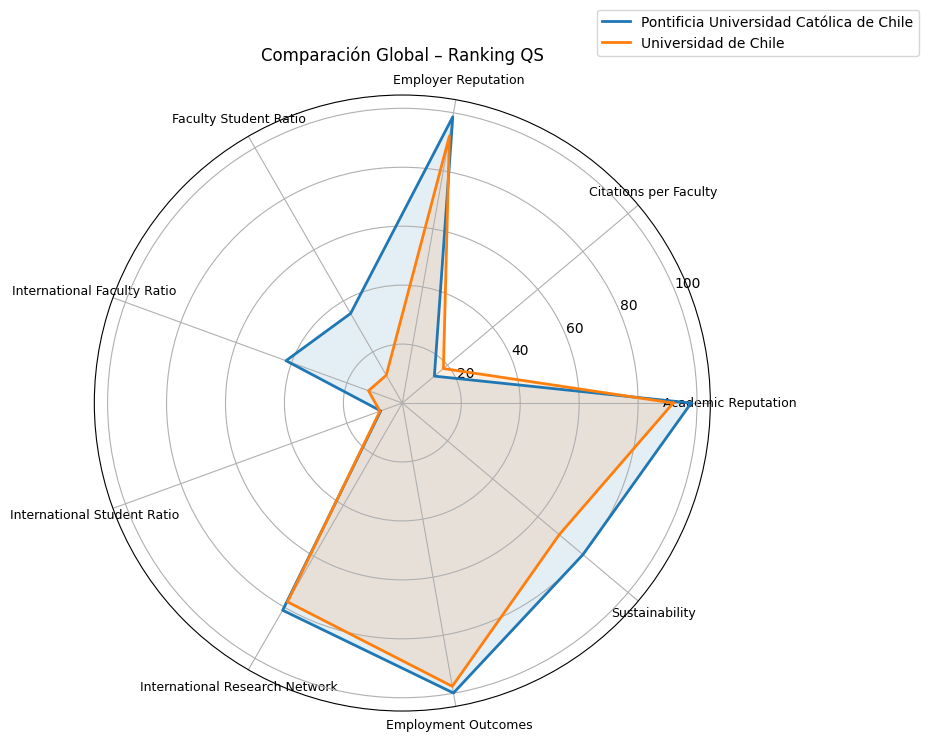


📊 PUNTAJES TOTALES (SITUACIÓN INICIAL)
────────────────────────────────────────────────────────────────────────────────────────────────────
🏫 Pontificia Universidad Católica de Chile (Referencia): 66.08
🟢 Universidad de Chile: 59.37 → por DEBAJO por 6.72

🔍 VARIABLES INDIVIDUALES
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                                          Pontificia Universid     Universidad de Chile
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Academic Reputation (30%)                                    98.0  🟢 ↑                     91.9
Citations per Faculty (20%)                                  14.2  🔴 ↓                     18.2
Employer Reputation (15%)                                    98.6  🟢

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# VARIABLES Y PESOS (QS)
# ======================================================

VARIABLES = {
    'AR SCORE': 0.30,
    'CPF SCORE': 0.20,
    'ER SCORE': 0.15,
    'FSR SCORE': 0.10,
    'IFR SCORE': 0.05,
    'ISR SCORE': 0.05,
    'IRN SCORE': 0.05,
    'EO SCORE': 0.05,
    'SUS SCORE': 0.05
}

NOMBRES = {
    'AR SCORE': 'Academic Reputation',
    'ER SCORE': 'Employer Reputation',
    'FSR SCORE': 'Faculty Student Ratio',
    'CPF SCORE': 'Citations per Faculty',
    'IFR SCORE': 'International Faculty Ratio',
    'ISR SCORE': 'International Student Ratio',
    'IRN SCORE': 'International Research Network',
    'EO SCORE': 'Employment Outcomes',
    'SUS SCORE': 'Sustainability'
}

# ======================================================
# FUNCIONES BASE
# ======================================================

def calcular_score(row):
    return sum(row[v] * w for v, w in VARIABLES.items())

def radar(datos, nombres):
    vars_ = list(VARIABLES.keys())
    labels = [NOMBRES[v] for v in vars_]

    angles = np.linspace(0, 2*np.pi, len(vars_), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for d, n in zip(datos, nombres):
        values = [d[v] for v in vars_] + [d[vars_[0]]]
        ax.plot(angles, values, linewidth=2, label=n)
        ax.fill(angles, values, alpha=0.12)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
    ax.set_title("Comparación Global – Ranking QS", pad=25)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
    plt.show()

# ======================================================
# ANÁLISIS ESTRATÉGICO
# ======================================================

def analisis_estrategico_avanzado(uni1, uni2, nombre1, nombre2):
    dificultad = {
        'AR SCORE': 0.9,
        'ER SCORE': 0.8,
        'CPF SCORE': 0.7,
        'EO SCORE': 0.6,
        'IRN SCORE': 0.5,
        'FSR SCORE': 0.4,
        'SUS SCORE': 0.3,
        'IFR SCORE': 0.2,
        'ISR SCORE': 0.2
    }

    estrategias = []

    for v, peso in VARIABLES.items():
        brecha = uni2[v] - uni1[v]
        mejora_realista = (100 - uni1[v]) * (1 - dificultad[v])
        impacto = mejora_realista * peso
        eficiencia = impacto / (dificultad[v] + 0.1)
        accion = "RECUPERAR" if brecha > 0 else "CONSOLIDAR"

        estrategias.append((v, brecha, impacto, eficiencia, accion, mejora_realista))

    estrategias.sort(key=lambda x: x[3], reverse=True)

    print(f"\n🎯 RUTA ESTRATÉGICA PARA {nombre1}")
    print("─" * 120)
    print(f"{'Variable':40}{'Brecha':>10}{'Impacto':>12}{'Eff':>8}{'Acción':>12}{'Meta':>10}")
    print("─" * 120)

    for v, brecha, imp, eff, acc, meta in estrategias[:]:
        print(
            f"{NOMBRES[v]} ({VARIABLES[v]*100:.0f}%)".ljust(40) +
            f"{brecha:>10.1f}{imp:>12.3f}{eff:>8.2f}{acc:>12}{meta:>10.1f}"
        )

# ======================================================
# COMPARADOR PRINCIPAL
# ======================================================

def comparar(df, indices, simular):
    datos = [df.iloc[i].copy() for i in indices]
    nombres = [d['Name'] for d in datos]

    radar(datos, nombres)

    scores = [calcular_score(d) for d in datos]

    print("\n📊 PUNTAJES TOTALES (SITUACIÓN INICIAL)")
    print("─" * 100)

    print(f"🏫 {nombres[0]} (Referencia): {scores[0]:.2f}")
    for i in range(1, len(scores)):
        brecha = scores[i] - scores[0]
        icon = "🔴" if brecha > 0 else "🟢" if brecha < 0 else "⚪"
        estado = "por ENCIMA" if brecha > 0 else "por DEBAJO" if brecha < 0 else "EMPATA"
        print(f"{icon} {nombres[i]}: {scores[i]:.2f} → {estado} por {abs(brecha):.2f}")

    # ==================================================
    # TABLA VARIABLES (EMOJIS SOLO EN UNI 1 Y SOLO SI SON 2)
    # ==================================================

    print("\n🔍 VARIABLES INDIVIDUALES")
    print("─" * 180)

    header = f"{'Variable':45}"
    for n in nombres:
        header += f"{n[:20]:>25}"
    print(header)
    print("─" * 180)

    for v, peso in VARIABLES.items():
        fila = f"{NOMBRES[v]} ({peso*100:.0f}%)".ljust(45)

        if len(datos) == 2:
            v1, v2 = datos[0][v], datos[1][v]
            if v1 > v2:
                emoji = "🟢 ↑"
            elif v1 < v2:
                emoji = "🔴 ↓"
            else:
                emoji = "⚪ ="
            fila += f"{v1:>20.1f} {emoji:>4}{v2:>25.1f}"
        else:
            for d in datos:
                fila += f"{d[v]:>25.1f}"

        print(fila)

    # ==================================================
    # SIMULACIÓN
    # ==================================================

    if simular:
        print("\n🔄 SIMULACIÓN DE MEJORA")
        vars_ = list(VARIABLES.keys())
        for i, v in enumerate(vars_, 1):
            print(f"{i}. {NOMBRES[v]}")

        idx = int(input("Selecciona variable: ")) - 1
        pct = float(input("Porcentaje de mejora: "))

        var = vars_[idx]
        base = datos[0][var]
        datos[0][var] = min(base * (1 + pct / 100), 100)

        nuevo_score = calcular_score(datos[0])

        print(f"\n📈 RESULTADO DE LA SIMULACIÓN")
        print(f"• Score original: {scores[0]:.2f}")
        print(f"• Score simulado: {nuevo_score:.2f}")
        print(f"• Ganancia total: +{nuevo_score - scores[0]:.2f}")

        if len(datos) == 2:
            print(f"• Brecha post-simulación: {scores[1] - nuevo_score:.2f}")

    if len(datos) >= 2:
        analisis_estrategico_avanzado(datos[0], datos[1], nombres[0], nombres[1])

    # ==================================================
    # EXPLICACIONES FINALES
    # ==================================================

    print("\n📘 DEFINICIONES")
    print("• Brecha: diferencia en puntaje total respecto a la universidad de referencia.")
    print("• Impacto: mejora potencial de una variable × su peso en el ranking.")
    print("• Eff (Eficiencia): impacto ajustado por la dificultad de mejorar esa variable.")
    print("• Meta: incremento máximo realista considerando restricciones estructurales.")
    print("• 🟢 Verde: la universidad de referencia está mejor posicionada.")
    print("• 🔴 Rojo: la universidad de referencia está peor posicionada.")

# ======================================================
# INTERFAZ
# ======================================================

def main():
    df = pd.read_csv("ranking_qs_chile_calculado.csv")

    print("\n🏫 UNIVERSIDADES DISPONIBLES")
    for i, n in enumerate(df['Name'], 1):
        print(f"{i:2d}. {n}")

    sel = input("\nSelecciona universidades (ej: 1,3): ")
    indices = [int(x.strip()) - 1 for x in sel.split(",")]

    sim = input("¿Deseas simular una mejora en la primera universidad? (s/n): ").lower() == "s"

    comparar(df, indices, sim)

if __name__ == "__main__":
    main()